# Quy trình Xử lý và Làm sạch Dữ liệu Game trên Steam

**Đồ án Môn học DS108 - Làm sạch & Tiền xử lý Dữ liệu**

Notebook này thực hiện trọn vẹn quy trình làm sạch và tiền xử lý dữ liệu cho tập dữ liệu các trò chơi trên Steam (giai đoạn 2022-2026).

## Các điểm sửa đổi cốt lõi đã áp dụng:
1. **Quy đổi giá tiền (Price Conversion)**: Sửa lỗi dữ liệu giá tiền bằng cách sử dụng thuộc tính `initialprice` (chuyển đổi từ cents → USD)
2. **Giới hạn thời gian chơi (Playtime Limitation)**: Ghi nhận việc API của SteamSpy trả về giá trị 0 cho tất cả các tựa game phát hành gần đây
3. **Lọc theo năm (Year Filtering)**: Giới hạn trong giai đoạn từ 2022-2026
4. **Kiểm soát chất lượng (Quality Control)**: Đặt ngưỡng tối thiểu từ 100 lượt đánh giá trở lên
5. **Khai phá đặc trưng (Feature Engineering)**: Mã hóa One-hot các thể loại (Genres) để chuẩn bị cho EDA & Mô hình hóa

## 1. Khởi tạo thư viện & Cấu hình

In [1]:
import pandas as pd
import numpy as np
import os
import ast
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Configuration
YEAR_MIN = 2022
YEAR_MAX = 2026
MIN_RATINGS = 100
DEVELOPER_MIN_GAMES = 3

# Setup plotting style
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")
print(f"Configuration: Year range {YEAR_MIN}-{YEAR_MAX}, Min ratings: {MIN_RATINGS}")

Libraries imported successfully!
Configuration: Year range 2022-2026, Min ratings: 100


## 2. Đọc dữ liệu từ file thô

In [2]:
# Load raw data from Steam APIs
INPUT_PATH = 'data/raw/steam_games_raw.csv'

if not os.path.exists(INPUT_PATH):
    alt_path = os.path.abspath(os.path.join('..', INPUT_PATH))
    if os.path.exists(alt_path):
        INPUT_PATH = alt_path
    else:
        raise FileNotFoundError(
            f"Raw data file not found. Checked:\n"
            f"  - {os.path.abspath('data/raw/steam_games_raw.csv')}\n"
            f"  - {alt_path}\n"
            "Please update INPUT_PATH or move the file into the expected data/raw directory."
        )

df = pd.read_csv(INPUT_PATH)
print(f"Raw data loaded: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Raw data loaded: (10284, 25)

Columns: ['appid', 'name', 'developer_x', 'publisher_x', 'score_rank', 'positive', 'negative', 'userscore', 'owners', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu', 'store_name', 'release_date', 'genres', 'developer_y', 'publisher_y', 'store_price', 'is_free', 'year']


## 3. Khám phá sơ bộ dữ liệu thô (Initial EDA on Raw Data)

Trước khi làm sạch, phân tích sơ bộ tập dữ liệu thô để xác định vấn đề chất lượng, outliers, cột không khả dụng. Quyết định làm sạch sẽ dựa trên thực tế dữ liệu.

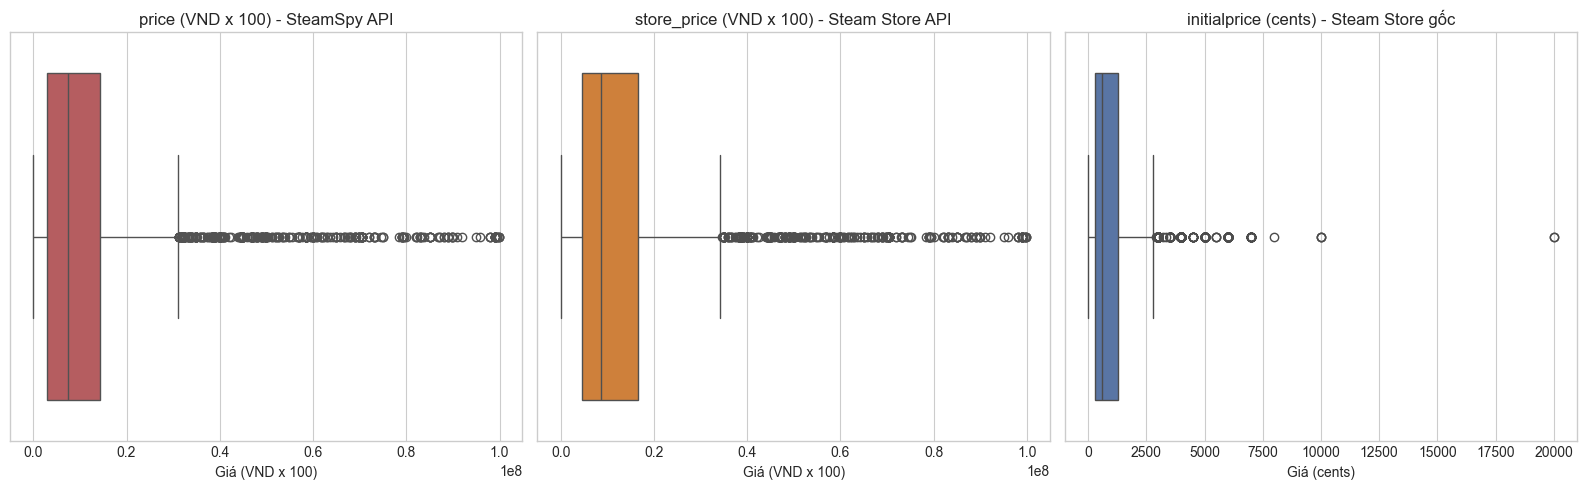

💡 QUAN SÁT:
 - price:       min=0.0, max=99900000.0, median=7350000.0
 - store_price: min=89.0, max=99900000.0, median=8750000.0
 - initialprice: min=0, max=19999, median=599.0

→ Cả price và store_price đều quy đổi VND, có outlier rất lớn (lên tới hàng trăm triệu VND).
  initialprice giữ cents gốc, phân phối hợp lý (max ~20,000 cents = $200).
  → Giải pháp: dùng initialprice / 100 để chuyển cents → USD.


In [3]:
# Kiểm tra outlier phân phối giá tiền (đơn vị gốc: VND x 100)
# Cả price và price_store đều quy đổi sang VND từ API, có nhiều outlier
# initialprice giữ giá gốc cents từ Steam Store
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# price: VND x 100 (SteamSpy API)
sns.boxplot(x=df['price'], color='#C44E52', ax=axes[0])
axes[0].set_title('price (VND x 100) - SteamSpy API')
axes[0].set_xlabel('Giá (VND x 100)')

# store_price: VND x 100 (Steam Store API)
sns.boxplot(x=df['store_price'], color='#E67E22', ax=axes[1])
axes[1].set_title('store_price (VND x 100) - Steam Store API')
axes[1].set_xlabel('Giá (VND x 100)')

# initialprice: cents gốc (Steam Store)
sns.boxplot(x=df['initialprice'], color='#4C72B0', ax=axes[2])
axes[2].set_title('initialprice (cents) - Steam Store gốc')
axes[2].set_xlabel('Giá (cents)')

plt.tight_layout()
plt.show()

print('💡 QUAN SÁT:')
print(f" - price:       min={df['price'].min()}, max={df['price'].max()}, median={df['price'].median()}")
print(f" - store_price: min={df['store_price'].min()}, max={df['store_price'].max()}, median={df['store_price'].median()}")
print(f" - initialprice: min={df['initialprice'].min()}, max={df['initialprice'].max()}, median={df['initialprice'].median()}")
print()
print('→ Cả price và store_price đều quy đổi VND, có outlier rất lớn (lên tới hàng trăm triệu VND).')
print('  initialprice giữ cents gốc, phân phối hợp lý (max ~20,000 cents = $200).')
print('  → Giải pháp: dùng initialprice / 100 để chuyển cents → USD.')


### Phân tích giá trị thiếu (Missing Values)

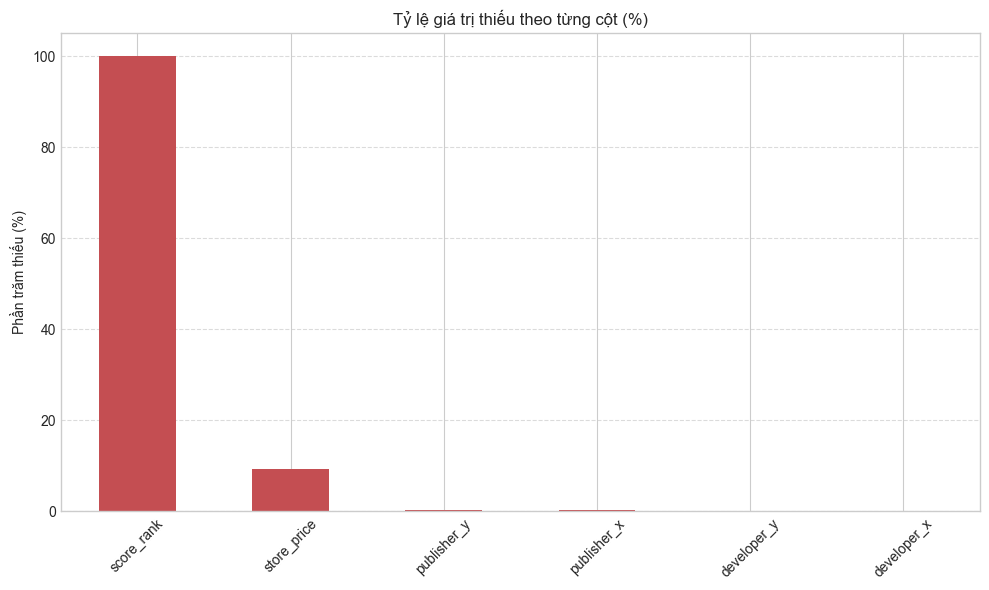

💡 QUAN SÁT: Cột 'score_rank' thiếu 100% dữ liệu. Việc giữ lại cột này là vô nghĩa và sẽ được loại bỏ trong bước cleaning.


In [4]:
# 2. Phân tích giá trị thiếu (Missing Values)
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df) * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
missing_pct[missing_pct > 0].plot(kind='bar', color='#C44E52')
plt.title('Tỷ lệ giá trị thiếu theo từng cột (%)')
plt.ylabel('Phần trăm thiếu (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"💡 QUAN SÁT: Cột 'score_rank' thiếu 100% dữ liệu. Việc giữ lại cột này là vô nghĩa và sẽ được loại bỏ trong bước cleaning.")

### Phân phối lượt đánh giá (Ratings Distribution)

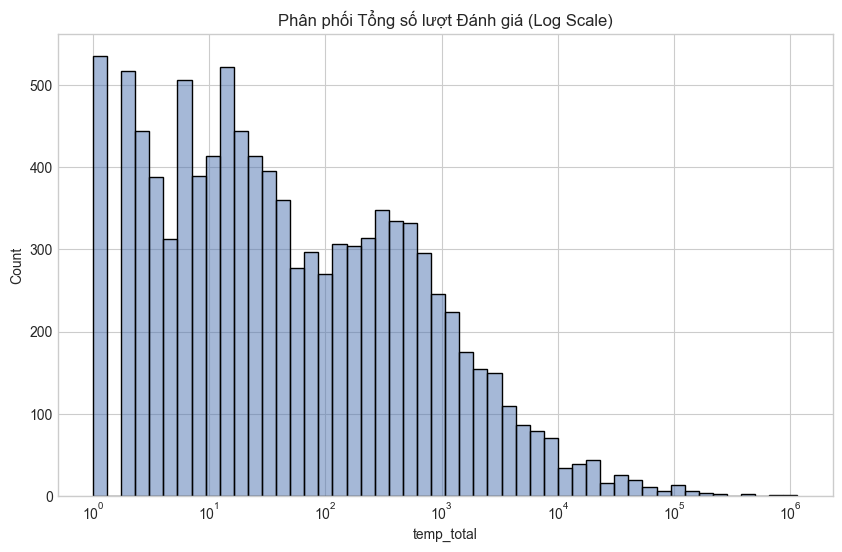

💡 QUAN SÁT: Một lượng lớn game có số lượt đánh giá cực thấp (dưới 100). Những dữ liệu này thường không đại diện cho chất lượng thực tế của game (nhiễu). Chúng ta sẽ thiết lập ngưỡng MIN_RATINGS = 100 để đảm bảo tính tin cậy của phân tích.


In [5]:
# 3. Kiểm tra phân phối lượt đánh giá (Ratings Distribution)
# Tính tổng ratings sơ bộ
df['temp_total'] = df['positive'] + df['negative']

plt.figure(figsize=(10, 6))
sns.histplot(df['temp_total'], bins=50, kde=True, color='#4C72B0', log_scale=True) # Thêm log_scale=True
plt.title('Phân phối Tổng số lượt Đánh giá (Log Scale)')
plt.show()
print("💡 QUAN SÁT: Một lượng lớn game có số lượt đánh giá cực thấp (dưới 100). Những dữ liệu này thường không đại diện cho chất lượng thực tế của game (nhiễu). Chúng ta sẽ thiết lập ngưỡng MIN_RATINGS = 100 để đảm bảo tính tin cậy của phân tích.")

## 4. Chuyển đổi định dạng ngày tháng

Chuyển cột `release_date` từ string sang `datetime` để có thể sắp xếp, lọc và tính toán khoảng cách thời gian.

In [6]:
# Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='raise')

# Verify
print('release_date dtype:', df['release_date'].dtype)
print('Range:', df['release_date'].min(), '->', df['release_date'].max())
print('Null after conversion:', df['release_date'].isnull().sum())


release_date dtype: datetime64[ns]
Range: 2022-01-01 00:00:00 -> 2026-05-14 00:00:00
Null after conversion: 0


## 4. Xử lý hậu tố và làm rõ tên cột
Đổi tên các cột sau khi gộp dữ liệu để phân biệt rõ chỉ số nào lấy từ **SteamSpy** (`_spy`) và chỉ số nào lấy từ **Steam Store** (`_store`).

In [7]:
# Rename columns for clarity and consistency
rename_map = {
    'positive': 'positive_ratings',
    'negative': 'negative_ratings',
    'average_forever': 'average_playtime',
    'developer_x': 'developer_spy',
    'developer_y': 'developer_store',
    'publisher_x': 'publisher_spy',
    'publisher_y': 'publisher_store',
    'price': 'price_spy',
    'store_price': 'price_store'
}
# Only rename columns that actually exist
rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
df = df.rename(columns=rename_map)
print('Columns renamed successfully!')
print(f'New columns: {list(df.columns)}')


Columns renamed successfully!
New columns: ['appid', 'name', 'developer_spy', 'publisher_spy', 'score_rank', 'positive_ratings', 'negative_ratings', 'userscore', 'owners', 'average_playtime', 'average_2weeks', 'median_forever', 'median_2weeks', 'price_spy', 'initialprice', 'discount', 'ccu', 'store_name', 'release_date', 'genres', 'developer_store', 'publisher_store', 'price_store', 'is_free', 'year', 'temp_total']


## 5. Xử lý giá trị thiếu & Gộp dữ liệu

In [8]:
# Use store data if available, else fallback to SteamSpy
df['developer'] = df['developer_store'].combine_first(df['developer_spy']).fillna('Unknown')
df['publisher'] = df['publisher_store'].combine_first(df['publisher_spy']).fillna('Unknown')

print(f"Cột 'developer' đã tạo: {df['developer'].notnull().sum()} giá trị (Đã lấp đầy khoảng trống bằng 'Unknown')")
print(f"Cột 'publisher' đã tạo: {df['publisher'].notnull().sum()} giá trị (Đã lấp đầy khoảng trống bằng 'Unknown')")

Cột 'developer' đã tạo: 10284 giá trị (Đã lấp đầy khoảng trống bằng 'Unknown')
Cột 'publisher' đã tạo: 10284 giá trị (Đã lấp đầy khoảng trống bằng 'Unknown')


## 6. Làm sạch và Quy đổi dữ liệu Giá tiền (Cents → USD)

### Vấn đề phát hiện

Các cột `price_spy` và `price_store` bị lỗi đơn vị (lên tới hàng triệu cents). Trường `initialprice` giữ giá gốc chuẩn.

**Giải pháp:** dùng `initialprice / 100` để quy đổi cents → USD, gán vào cột `price`.

In [9]:
# Show the problem: corrupted price values
print("BEFORE FIX - Price distribution:")
print(f"  Price field: min={df['price_spy'].min()}, max={df['price_spy'].max()}, median={df['price_spy'].median()}")
print(f"  Store price field: min={df['price_store'].min()}, max={df['price_store'].max()}, median={df['price_store'].median()}")
print(f"  Initial price field: min={df['initialprice'].min()}, max={df['initialprice'].max()}, median={df['initialprice'].median()}")

# Show examples of corrupted values
extreme_prices = df[df['price_spy'] > 10000][['name', 'price_spy', 'price_store', 'initialprice']].head(5)
print("\nExamples of corrupted price values:")
print(extreme_prices)

BEFORE FIX - Price distribution:
  Price field: min=0.0, max=99900000.0, median=7350000.0
  Store price field: min=89.0, max=99900000.0, median=8750000.0
  Initial price field: min=0, max=19999, median=599.0

Examples of corrupted price values:
                             name   price_spy  price_store  initialprice
0                        Palworld  38500000.0   38500000.0          2999
4                  Lethal Company  14200000.0   14200000.0           999
6  Warhammer 40,000: Rogue Trader  58500000.0   58500000.0          4999
7                        R.E.P.O.     44900.0      44900.0           999
9                 Resident Evil 4  85000000.0   85000000.0          3999


In [10]:
# Apply the fix: Use initialprice and convert from cents to USD
df['price'] = pd.to_numeric(df['initialprice'], errors='coerce') / 100
df['price'] = df['price'].fillna(0)

print("AFTER FIX - Price distribution:")
print(f"  Price: min=${df['price'].min():.2f}, max=${df['price'].max():.2f}, median=${df['price'].median():.2f}")
print(f"  Mean: ${df['price'].mean():.2f}")

AFTER FIX - Price distribution:
  Price: min=$0.00, max=$199.99, median=$5.99
  Mean: $9.66


## 7. Tạo nhãn biễn phân loại nhị phân Is_Free

In [11]:
# Create binary flag for free-to-play games
df['is_free'] = (df['price'] == 0).astype(int)

print(f"Free games: {df['is_free'].sum()} ({df['is_free'].mean()*100:.1f}%)")
print(f"Paid games: {(df['is_free'] == 0).sum()} ({(df['is_free'] == 0).mean()*100:.1f}%)")

Free games: 769 (7.5%)
Paid games: 9515 (92.5%)


## 8. Chuyển đổi định dạng & Tỷ lệ đánh giá

In [12]:
# Function to split text-based range (e.g., '20,000 .. 50,000') into numeric columns for calculation.
def parse_owners(owners_str):
    if pd.isna(owners_str) or '..' not in str(owners_str):
        return 0, 0, 0
    parts = str(owners_str).split('..')
    try:
        low = int(parts[0].replace(',', '').strip())
        high = int(parts[1].replace(',', '').strip())
        mid = int((low + high) / 2)
        return low, high, mid
    except:
        return 0, 0, 0

# Apply the parsing function to the owners column
owners_parsed = df['owners'].apply(parse_owners)
df['owners_min'] = [x[0] for x in owners_parsed]
df['owners_max'] = [x[1] for x in owners_parsed]
df['owners_midpoint'] = [x[2] for x in owners_parsed]

print("Successfully parsed 'owners' column! Added numeric columns: owners_min, owners_max, owners_midpoint")
print(df[['owners', 'owners_min', 'owners_max', 'owners_midpoint']].head(5))

Successfully parsed 'owners' column! Added numeric columns: owners_min, owners_max, owners_midpoint
                      owners  owners_min  owners_max  owners_midpoint
0  50,000,000 .. 100,000,000    50000000   100000000         75000000
1  50,000,000 .. 100,000,000    50000000   100000000         75000000
2  50,000,000 .. 100,000,000    50000000   100000000         75000000
3   20,000,000 .. 50,000,000    20000000    50000000         35000000
4   10,000,000 .. 20,000,000    10000000    20000000         15000000


In [13]:
# Ensure rating columns are numeric
df['positive_ratings'] = pd.to_numeric(df['positive_ratings'], errors='coerce').fillna(0).astype(int)
df['negative_ratings'] = pd.to_numeric(df['negative_ratings'], errors='coerce').fillna(0).astype(int)

# Calculate total ratings and rating ratio
df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']
df['rating_ratio'] = df['positive_ratings'] / df['total_ratings'].replace(0, np.nan)
df['rating_ratio'] = df['rating_ratio'].fillna(0)

print("Rating calculations complete!")
print(f"Total ratings range: {df['total_ratings'].min()} - {df['total_ratings'].max()}")
print(f"Rating ratio range: {df['rating_ratio'].min():.3f} - {df['rating_ratio'].max():.3f}")

Rating calculations complete!
Total ratings range: 0 - 1150098
Rating ratio range: 0.000 - 1.000


In [14]:
# Calculate Wilson Score (Lower Bound) to mitigate Survivorship Bias
# Z = 1.95996 for 95% confidence interval
z = 1.95996
phat = df['positive_ratings'] / df['total_ratings']
n = df['total_ratings']
z2 = z**2

df['wilson_score'] = (phat + z2/(2*n) - z * np.sqrt((phat*(1-phat) + z2/(4*n))/n)) / (1 + z2/n)

print("✅ Wilson Score calculated and added to dataframe!")
print(df[['name', 'rating_ratio', 'wilson_score']].head())

✅ Wilson Score calculated and added to dataframe!
                              name  rating_ratio  wilson_score
0                         Palworld      0.941049      0.940297
1  Call of Duty: Modern Warfare II      0.587573      0.586431
2               Black Myth: Wukong      0.966631      0.966301
3             Monster Hunter Wilds      0.582712      0.580642
4                   Lethal Company      0.971800      0.971331


## 9. Thời gian chơi không khả dụng

**CRITICAL FINDING:** SteamSpy API returns 0 for `average_forever` field for all recent games (2023-2026).

This is a known limitation of the SteamSpy API and prevents playtime-based analysis.

In [15]:
# Verify playtime is all zeros
print(f"Playtime statistics:")
print(f"  Min: {df['average_playtime'].min()} minutes")
print(f"  Max: {df['average_playtime'].max()} minutes")
print(f"  Non-zero values: {(df['average_playtime'] > 0).sum()} out of {len(df)}")
print(f"\n⚠️  NOTE: Playtime data unavailable from SteamSpy API for recent games.")
print("This field will be set to 0 for all records.")

# Explicitly set to 0 (documenting the limitation)
df['average_playtime'] = 0

Playtime statistics:
  Min: 0 minutes
  Max: 0 minutes
  Non-zero values: 0 out of 10284

⚠️  NOTE: Playtime data unavailable from SteamSpy API for recent games.
This field will be set to 0 for all records.


## 10. Lọc loại bỏ các Game có số lượng đánh giá quá thấp (Dữ liệu nhiễu)

In [16]:
# Filter to ensure data reliability
before = len(df)
df = df[df['total_ratings'] > MIN_RATINGS]
removed = before - len(df)

print(f"Filtered games with < {MIN_RATINGS} ratings:")
print(f"  Before: {before} games")
print(f"  After: {len(df)} games")
print(f"  Removed: {removed} games ({removed/before*100:.1f}%)")

Filtered games with < 100 ratings:
  Before: 10284 games
  After: 3868 games
  Removed: 6416 games (62.4%)


## 11. Phân nhóm phân khúc giá tiền

In [17]:
# Price bin rationale:
# - [-0.01, 0.001): Free games (price = 0)
# - [0.001, 10): Budget games (<$10)  
# - [10, 30): Mid-range games ($10-30)
# - [30, inf): Premium games (>$30)
price_bins = [-0.01, 0.001, 10, 30, np.inf]
price_labels = ['Free', '<$10', '$10-30', '>$30']

df['price_group'] = pd.cut(df['price'], bins=price_bins, labels=price_labels, right=False)

print("Price groups created successfully (fixed $0.99 edge case):")
print(df['price_group'].value_counts().sort_index())

Price groups created successfully (fixed $0.99 edge case):
price_group
Free       256
<$10      1568
$10-30    1679
>$30       365
Name: count, dtype: int64


## 12. Xóa cột thừa

In [18]:
# Columns to drop - Rationale:
# 1. score_rank: 100% missing (all NaN)
# 2. userscore: Không đáng tin, Steam không dùng cho ranking
# 3. average_2weeks, median_2weeks: API trả 0 cho tất cả games
# 4. median_forever, average_playtime: API trả 0 cho tất cả games
cols_to_drop = ['score_rank', 'userscore', 'average_2weeks', 'median_forever', 'median_2weeks', 'average_playtime']

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
print(f"Useless/empty columns dropped successfully! Number of remaining columns in the model: {len(df.columns)}")

Useless/empty columns dropped successfully! Number of remaining columns in the model: 30


## 13. Mã hóa One-Hot cho Đặc trưng Thể loại (Genre Encoding)
Chuyển đổi chuỗi danh sách các thể loại thành các biến nhị phân độc lập.

In [19]:
print("Đang xử lý phân rã chuỗi thể loại...")

# Hàm chuyển đổi chuỗi an toàn
def parse_genres(x):
    if pd.isna(x): return []
    try:
        return ast.literal_eval(x) if isinstance(x, str) else x
    except (ValueError, SyntaxError):
        return []

# Chuyển chuỗi thành list thực tế
df['genres_list'] = df['genres'].apply(parse_genres)

# Mã hóa One-Hot
genres_encoded = df['genres_list'].str.join('|').str.get_dummies()
genres_encoded = genres_encoded.add_prefix('genre_')

# Gộp vào DataFrame chính và xóa cột tạm
df = pd.concat([df, genres_encoded], axis=1)
df = df.drop(columns=['genres_list'])

genre_cols = [col for col in df.columns if col.startswith('genre_')]
print(f"✅ Đã tạo thành công {len(genre_cols)} cột thể loại mới!")

Đang xử lý phân rã chuỗi thể loại...
✅ Đã tạo thành công 22 cột thể loại mới!


## 14. Bảng thống kê mô tả tóm tắt (Cleaned Data)

In [20]:
# Basic statistics for key variables
print("=" * 60)
print("CLEANED DATA SUMMARY STATISTICS")
print("=" * 60)

stats_df = df[['price', 'rating_ratio', 'wilson_score', 'total_ratings']].describe()
print(stats_df.round(2))

CLEANED DATA SUMMARY STATISTICS
         price  rating_ratio  wilson_score  total_ratings
count  3868.00       3868.00       3868.00        3868.00
mean     15.54          0.83          0.80        4137.53
std      13.88          0.13          0.14       27448.71
min       0.00          0.09          0.05         101.00
25%       5.99          0.77          0.72         250.00
50%      11.99          0.86          0.83         550.50
75%      19.99          0.93          0.90        1616.75
max      99.99          1.00          0.99     1150098.00


## 15. Kiểm định chất lượng & Lưu dữ liệu mới

In [21]:
# Create output directory
# LƯU Ý: Đã thay đổi tên file lưu thành 'steam_games_with_genres.csv'
os.makedirs('../data/processed', exist_ok=True)
OUTPUT_PATH = '../data/processed/steam_games_with_genres.csv'
df.to_csv(OUTPUT_PATH, index=False)

print(f"Cleaned data saved to: {OUTPUT_PATH}")
print(f"Final shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")

# ============================================================
# DATA QUALITY ASSERTIONS
# ============================================================
def assert_data_quality(df):
    # Check for negative prices
    assert (df['price'] >= 0).all(), "Negative prices detected!"
    
    # Check rating_ratio is between 0 and 1
    assert (df['rating_ratio'] >= 0).all(), "Rating ratio below 0!"
    assert (df['rating_ratio'] <= 1).all(), "Rating ratio above 1!"
    
    # Check wilson_score is between 0 and 1
    assert (df['wilson_score'] >= 0).all(), "Wilson score below 0!"
    assert (df['wilson_score'] <= 1).all(), "Wilson score above 1!"
    
    # Check total_ratings is positive
    assert (df['total_ratings'] > 0).all(), "Zero or negative total_ratings detected!"
    
    # Check year is within expected range
    assert df['year'].between(2022, 2026).all(), "Year out of expected range (2022-2026)!"
    
    # Check for duplicate appids
    assert df['appid'].nunique() == len(df), "Duplicate appids detected!"
    
    # Check if One-Hot Encoding was successful
    assert any(col.startswith('genre_') for col in df.columns), "Genre one-hot encoding is missing!"
    
    print("✅ All data quality assertions passed!")

# Run data quality checks
assert_data_quality(df)

Cleaned data saved to: ../data/processed/steam_games_with_genres.csv
Final shape: (3868, 52)
Columns: ['appid', 'name', 'developer_spy', 'publisher_spy', 'positive_ratings', 'negative_ratings', 'owners', 'price_spy', 'initialprice', 'discount', 'ccu', 'store_name', 'release_date', 'genres', 'developer_store', 'publisher_store', 'price_store', 'is_free', 'year', 'temp_total', 'developer', 'publisher', 'price', 'owners_min', 'owners_max', 'owners_midpoint', 'total_ratings', 'rating_ratio', 'wilson_score', 'price_group', 'genre_Accounting', 'genre_Action', 'genre_Adventure', 'genre_Animation & Modeling', 'genre_Audio Production', 'genre_Casual', 'genre_Design & Illustration', 'genre_Early Access', 'genre_Education', 'genre_Free To Play', 'genre_Game Development', 'genre_Indie', 'genre_Massively Multiplayer', 'genre_Photo Editing', 'genre_RPG', 'genre_Racing', 'genre_Simulation', 'genre_Sports', 'genre_Strategy', 'genre_Utilities', 'genre_Video Production', 'genre_Web Publishing']

✅ All d